In [12]:
import pandas as pd
import os
import numpy as np

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
project_path = os.getcwd()
print('project path = ' , project_path)

file_path = project_path + '/diabetes2.xlsx'
print('file path =' , file_path)

df = pd.read_excel(file_path)
print(df)

# Show first rows
print(df.head())

# -----------------------------
# Data Cleaning (VERY IMPORTANT)
# -----------------------------

# Replace 0 with NaN in important columns
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

# Fill missing values with median
df.fillna(df.median(), inplace=True)

# -----------------------------
# Split data
# -----------------------------
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Train Logistic Regression
# -----------------------------
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

project path =  /Users/pulkit/Desktop/untitled folder 2
file path = /Users/pulkit/Desktop/untitled folder 2/diabetes2.xlsx
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        

In [14]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578

In [15]:
# New patient data
# Format:
# [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]

new_data = [[5, 140, 80, 25, 100, 30.5, 0.5, 35]]

# Scale it
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)

# Output
if prediction[0] == 1:
    print("🔴 Diabetic")
else:
    print("🟢 Not Diabetic")

🔴 Diabetic


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


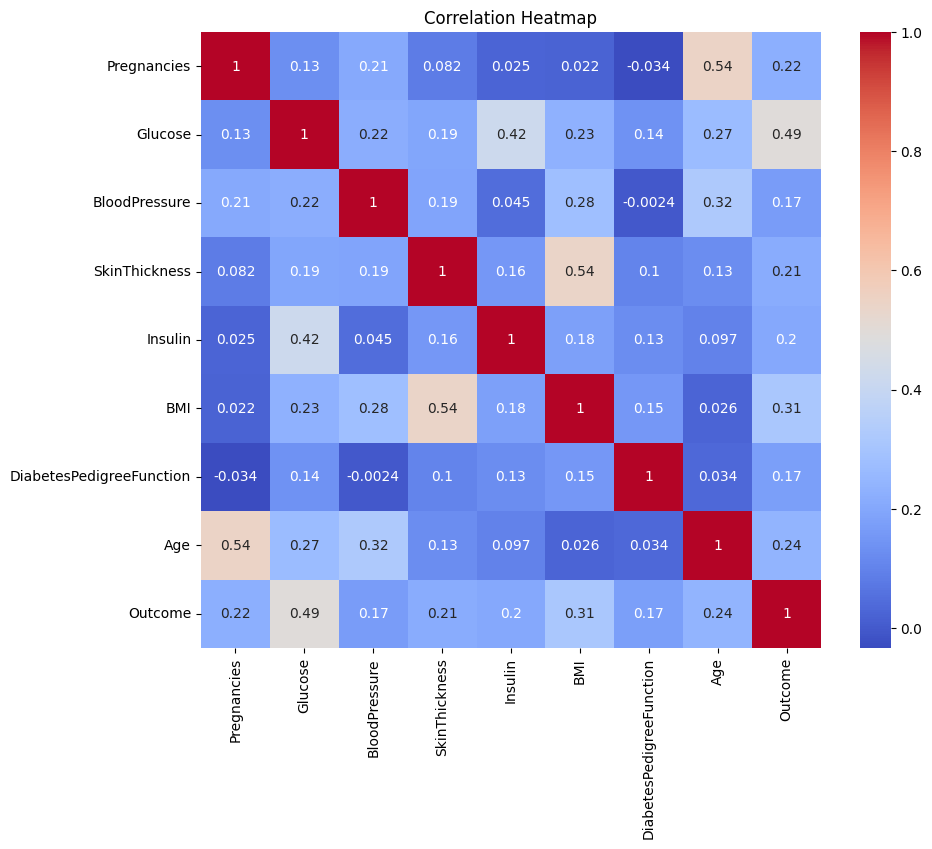

In [16]:
#correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

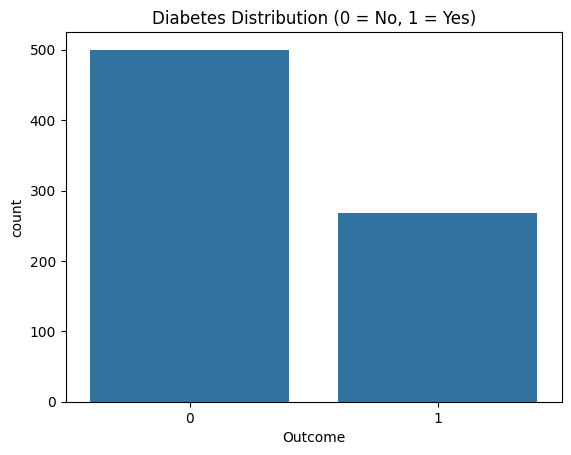

In [17]:
#diabetes distribution
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Distribution (0 = No, 1 = Yes)")
plt.show()

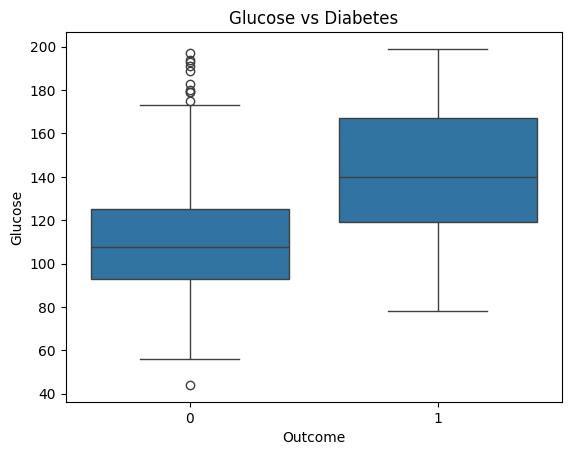

In [18]:
#glucose vs outcome
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose vs Diabetes")
plt.show()

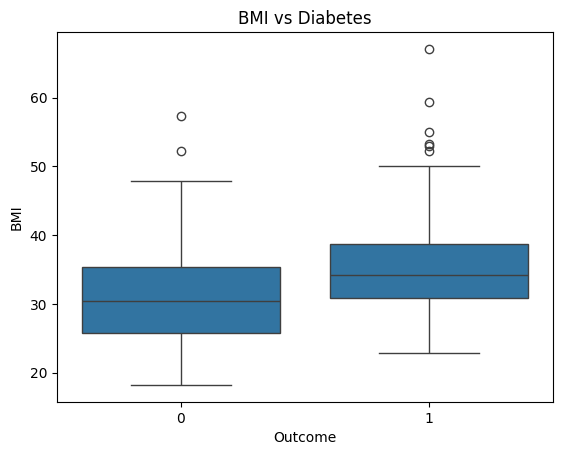

In [19]:
#BMI vs outcome
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI vs Diabetes")
plt.show()

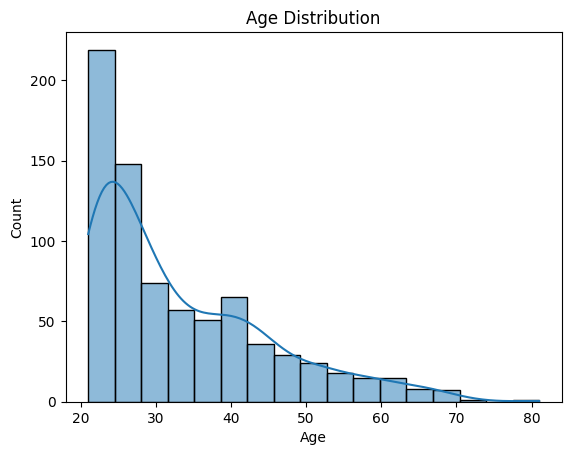

In [20]:
#age distribution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

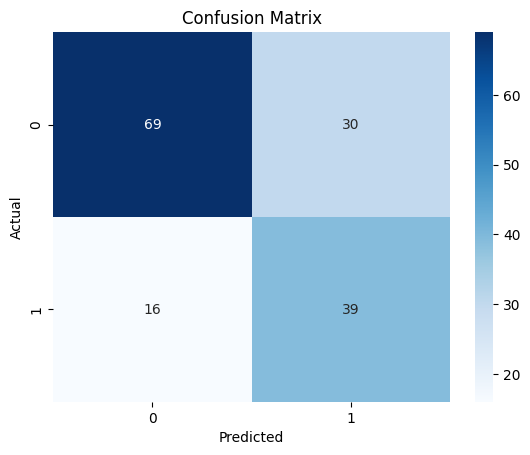

In [21]:
#confusion matrix graph
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()